# Littering Detection from Fixed-Camera Video

End-to-end pipeline that detects littering events in surveillance-style video:

1. Loads YOLO-format annotations (person + trash)
2. Optionally downloads extra training data from Open Images V7
3. Fine-tunes YOLO11m on the merged dataset
4. Runs detection + ByteTrack on input videos
5. Flags littering events using silent calibration + carry-check + proximity + temporal confirmation
6. Saves annotated videos, evidence screenshots, and graphs in tidy folders

---

### Datasets used

| Source | Images | Purpose |
|---|---|---|
| **Local Roboflow export** (`train/`, `valid/`) | 222 | Domain-specific person + trash. [Roboflow Universe](https://universe.roboflow.com/xfares/littering-detection-nciat/dataset/1) |
| **Open Images V7** (via FiftyOne) | ~600 | Generic Person / Bottle / Tin can / Plastic bag / Waste container. [Open Images V7](https://storage.googleapis.com/openimages/web/index.html) |
| **YOLO11m COCO weights** | — | Pretrained backbone. [Ultralytics docs](https://docs.ultralytics.com/models/yolo11/) |

### Project folder layout (auto-created)

```
<this notebook's folder>/
  input/         <- drop your videos here
  outputs/       <- annotated videos go directly here
  evidence/      <- one JPG per detected event
  graphs/        <- every visualization saved here
  dataset_merged/  extra_data/  littering_model/  train/  valid/
  littering_detection.ipynb
```

`PROJECT_DIR` is auto-detected from the notebook's working directory.


## 0. Configuration

One cell controls every stage.

In [1]:
# ============================================================
# CONFIG  -- toggle stages and tune detection here
# ============================================================
from pathlib import Path

# Auto-detect project dir: the folder containing this notebook
PROJECT_DIR = Path.cwd().resolve()
print(f"Project directory: {PROJECT_DIR}")

# Stage skip flags
SKIP_INSTALL  = True
SKIP_DOWNLOAD = True
SKIP_MERGE    = True
SKIP_TRAIN    = True    # True => reuse existing best.pt
SKIP_EVAL     = True

# Training hyperparameters
EPOCHS = 100             # auto-reduced to 50 on CPU
IMGSZ  = 640
BATCH  = 8

# Inference hyperparameters
CONF_THRESH      = 0.30
PROXIMITY_PX     = 320
CALIBRATION_SEC  = 2.0
NEW_TRASH_SEC    = 10.0
ESTABLISHED_SEC  = 60.0
KNOWN_DIST_PX    = 100
BANNER_SEC       = 2.5

# Warning reliability knobs
CONFIRM_FRAMES   = 2
TRACK_MERGE_PX   = 70
CONF_SMOOTH_WIN  = 5
MIN_AVG_CONF     = 0.30

# Carry-check: trash sitting in the upper N% of a person's bbox is being held
CARRIED_TOP_FRAC = 0.60

# Recent-event suppression: new event blocked within R pixels of a fire in last W seconds
RECENT_EVENT_RADIUS_PX = 200
RECENT_EVENT_WINDOW_SEC = 2.0

CLASS_NAMES = ["person", "trash"]
VIDEO_FPS   = 25.0


Project directory: C:\Users\fares\Downloads\manual_video_annotations 2


## 1. Setup

In [2]:
# ── Install dependencies ────────────────────────────────────
import subprocess, sys

PACKAGES = [
    "ultralytics>=8.3.0",
    "opencv-python-headless",
    "matplotlib",
    "Pillow",
    "tqdm",
    "PyYAML",
    "pandas",
    "fiftyone",
]

if SKIP_INSTALL:
    print("SKIP_INSTALL=True -> skipping pip install")
else:
    print("Installing dependencies ...")
    for pkg in PACKAGES:
        r = subprocess.run(
            [sys.executable, "-m", "pip", "install", pkg, "-q", "--disable-pip-version-check"],
            capture_output=True, text=True,
        )
        print(f"  [{'OK' if r.returncode == 0 else 'FAIL'}] {pkg}")
    print("Done.")


SKIP_INSTALL=True -> skipping pip install


In [3]:
# ── Imports + folder layout + device ────────────────────────
import os, shutil, random, warnings
from pathlib import Path
from datetime import datetime
from collections import deque, defaultdict

import numpy as np
import cv2
import yaml
import torch
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from tqdm import tqdm
from ultralytics import YOLO

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

# Folder layout -- four output folders are siblings at project root
TRAIN_IMGS   = PROJECT_DIR / "train" / "images"
TRAIN_LBLS   = PROJECT_DIR / "train" / "labels"
VALID_IMGS   = PROJECT_DIR / "valid" / "images"
VALID_LBLS   = PROJECT_DIR / "valid" / "labels"
INPUT_DIR    = PROJECT_DIR / "input"
OUTPUT_DIR   = PROJECT_DIR / "outputs"
EVIDENCE_DIR = PROJECT_DIR / "evidence"
GRAPHS_DIR   = PROJECT_DIR / "graphs"
MERGED_DIR   = PROJECT_DIR / "dataset_merged"
EXTRA_DIR    = PROJECT_DIR / "extra_data"
MODEL_DIR    = PROJECT_DIR / "littering_model"

for d in [INPUT_DIR, OUTPUT_DIR, EVIDENCE_DIR, GRAPHS_DIR,
          MERGED_DIR, EXTRA_DIR, MODEL_DIR]:
    d.mkdir(exist_ok=True)

if torch.cuda.is_available():
    DEVICE = "0"; print(f"GPU: {torch.cuda.get_device_name(0)}")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = "mps"; print("Apple Silicon MPS")
else:
    DEVICE = "cpu"; print("CPU only -- training will be slow; consider Colab")

if DEVICE == "cpu":
    EPOCHS = min(EPOCHS, 50)

print("\nFolder layout:")
print(f"  Input            -> {INPUT_DIR}")
print(f"  Annotated videos -> {OUTPUT_DIR}")
print(f"  Event evidence   -> {EVIDENCE_DIR}")
print(f"  Graphs           -> {GRAPHS_DIR}")


GPU: NVIDIA GeForce RTX 4050 Laptop GPU

Folder layout:
  Input            -> C:\Users\fares\Downloads\manual_video_annotations 2\input
  Annotated videos -> C:\Users\fares\Downloads\manual_video_annotations 2\outputs
  Event evidence   -> C:\Users\fares\Downloads\manual_video_annotations 2\evidence
  Graphs           -> C:\Users\fares\Downloads\manual_video_annotations 2\graphs


## 2. Dataset Analysis

The Roboflow export mixes two YOLO formats:

- **Polygon** — `class_id x1 y1 x2 y2 ... xN yN` (person outlines)
- **Bounding box** — `class_id cx cy w h` (most trash)

Section 3 normalises both to `cx cy w h`.


In [4]:
# ── Audit raw label files ───────────────────────────────────
def audit_labels(lbl_dir):
    stats = {"images": 0, "annotations": 0, "polygon": 0, "bbox": 0, "classes": {}}
    for fp in sorted(Path(lbl_dir).glob("*.txt")):
        stats["images"] += 1
        for line in open(fp):
            parts = line.strip().split()
            if not parts:
                continue
            cls = int(parts[0])
            stats["annotations"] += 1
            stats["classes"][cls] = stats["classes"].get(cls, 0) + 1
            if len(parts) - 1 > 4:
                stats["polygon"] += 1
            else:
                stats["bbox"] += 1
    return stats

t = audit_labels(TRAIN_LBLS)
v = audit_labels(VALID_LBLS)

print(f"{'Split':<8}{'Images':>8}{'Annots':>8}{'Person':>8}{'Trash':>8}{'Poly':>7}{'BBox':>7}")
print("-" * 54)
for name, s in [("train", t), ("valid", v)]:
    print(f"{name:<8}{s['images']:>8}{s['annotations']:>8}"
          f"{s['classes'].get(0,0):>8}{s['classes'].get(1,0):>8}"
          f"{s['polygon']:>7}{s['bbox']:>7}")


Split     Images  Annots  Person   Trash   Poly   BBox
------------------------------------------------------
train        178     538     219     319    218    320
valid         44     136      52      84     52     84


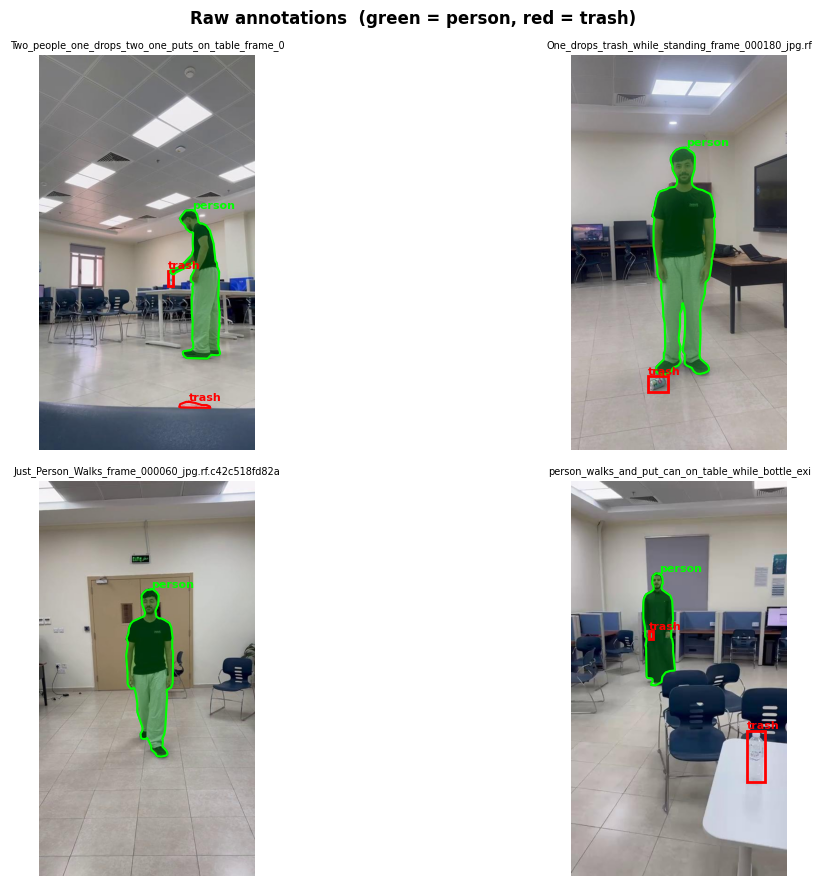

Saved -> C:\Users\fares\Downloads\manual_video_annotations 2\graphs\annotation_samples.png


In [5]:
# ── Sample annotations grid (saved to graphs/) ──────────────
def draw_annotations(img_dir, lbl_dir, n=4, save_to=None):
    imgs = sorted(Path(img_dir).glob("*.jpg"))
    samples = random.sample(imgs, min(n, len(imgs)))
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    for ax, p in zip(axes.flat, samples):
        img = np.array(Image.open(p).convert("RGB"))
        h, w = img.shape[:2]
        ax.imshow(img)
        lp = Path(lbl_dir) / (p.stem + ".txt")
        if lp.exists():
            for line in open(lp):
                parts = list(map(float, line.strip().split()))
                if not parts:
                    continue
                cls    = int(parts[0])
                coords = parts[1:]
                color  = "lime" if cls == 0 else "red"
                label  = CLASS_NAMES[cls]
                if len(coords) > 4:
                    pts = np.array(coords).reshape(-1, 2)
                    xs, ys = pts[:, 0] * w, pts[:, 1] * h
                    ax.fill(xs, ys, alpha=0.2, color=color)
                    ax.plot(np.append(xs, xs[0]), np.append(ys, ys[0]),
                            color=color, lw=1.5)
                    ax.text(xs[0], ys[0]-5, label, color=color, fontsize=8, fontweight="bold")
                else:
                    cx, cy, bw, bh = coords
                    x1, y1 = (cx-bw/2)*w, (cy-bh/2)*h
                    ax.add_patch(patches.Rectangle((x1, y1), bw*w, bh*h,
                                                   linewidth=2, edgecolor=color, facecolor="none"))
                    ax.text(x1, y1-5, label, color=color, fontsize=8, fontweight="bold")
        ax.set_title(p.name[:50], fontsize=7)
        ax.axis("off")
    plt.suptitle("Raw annotations  (green = person, red = trash)", fontweight="bold")
    plt.tight_layout()
    if save_to:
        plt.savefig(save_to, dpi=120, bbox_inches="tight")
    plt.show()

out_png = GRAPHS_DIR / "annotation_samples.png"
draw_annotations(TRAIN_IMGS, TRAIN_LBLS, save_to=out_png)
print(f"Saved -> {out_png}")


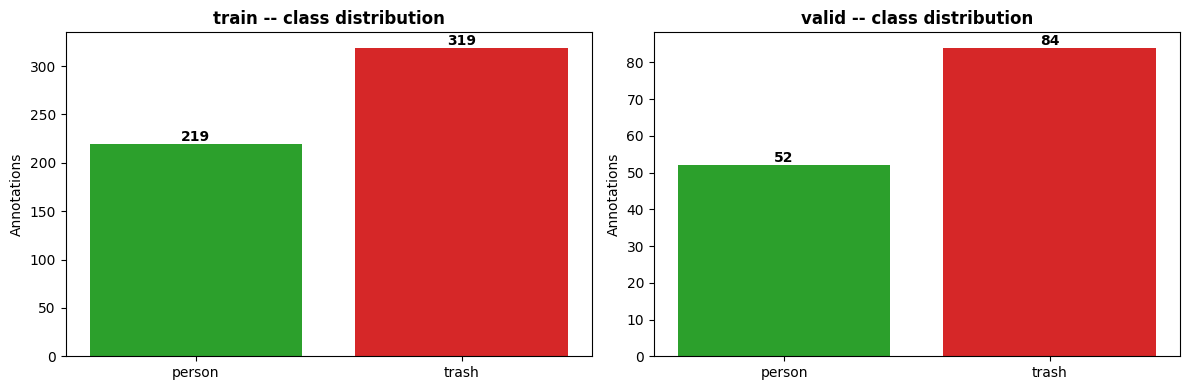

Saved -> C:\Users\fares\Downloads\manual_video_annotations 2\graphs\class_distribution.png


In [6]:
# ── Class distribution bar chart (saved to graphs/) ─────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, s) in zip(axes, [("train", t), ("valid", v)]):
    counts = [s["classes"].get(i, 0) for i in range(len(CLASS_NAMES))]
    bars = ax.bar(CLASS_NAMES, counts, color=["#2ca02c", "#d62728"])
    ax.set_title(f"{name} -- class distribution", fontweight="bold")
    ax.set_ylabel("Annotations")
    for b, c in zip(bars, counts):
        ax.text(b.get_x() + b.get_width()/2, b.get_height(), str(c),
                ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
out_png = GRAPHS_DIR / "class_distribution.png"
plt.savefig(out_png, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved -> {out_png}")


## 3. Dataset Preparation  (skippable: `SKIP_MERGE = True`)

Polygon → bounding box conversion:

```
cx = (xmin + xmax) / 2,  cy = (ymin + ymax) / 2
w  = xmax - xmin,        h  = ymax - ymin
```

Coordinates clipped to `[0, 1]`, written to `dataset_merged/`.


In [7]:
# ── Polygon -> bbox conversion + split copy ─────────────────
def convert_label_file(lbl_path):
    out = []
    for line in open(lbl_path):
        parts = line.strip().split()
        if not parts:
            continue
        cls_id = parts[0]
        coords = list(map(float, parts[1:]))
        if len(coords) == 4:
            out.append(" ".join([cls_id] + [f"{c:.6f}" for c in coords]))
        elif len(coords) >= 6:
            pts = np.array(coords).reshape(-1, 2)
            xmin, ymin = pts.min(axis=0)
            xmax, ymax = pts.max(axis=0)
            cx = float(np.clip((xmin + xmax) / 2, 0, 1))
            cy = float(np.clip((ymin + ymax) / 2, 0, 1))
            bw = float(np.clip(xmax - xmin, 1e-4, 1))
            bh = float(np.clip(ymax - ymin, 1e-4, 1))
            out.append(f"{cls_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")
    return out

def build_split(img_src, lbl_src, split_name):
    dst_i = MERGED_DIR / split_name / "images"
    dst_l = MERGED_DIR / split_name / "labels"
    dst_i.mkdir(parents=True, exist_ok=True)
    dst_l.mkdir(parents=True, exist_ok=True)
    n = 0
    for img_path in sorted(Path(img_src).glob("*.jpg")):
        lbl = Path(lbl_src) / (img_path.stem + ".txt")
        if not lbl.exists():
            continue
        lines = convert_label_file(lbl)
        if not lines:
            continue
        shutil.copy2(img_path, dst_i / img_path.name)
        (dst_l / (img_path.stem + ".txt")).write_text("\n".join(lines))
        n += 1
    return n

if SKIP_MERGE:
    n_tr = len(list((MERGED_DIR / "train" / "images").glob("*.jpg")))
    n_vl = len(list((MERGED_DIR / "valid" / "images").glob("*.jpg")))
    print(f"SKIP_MERGE=True -> reusing existing merged dataset ({n_tr} train, {n_vl} valid)")
else:
    print("Converting annotations ...")
    n_tr = build_split(TRAIN_IMGS, TRAIN_LBLS, "train")
    n_vl = build_split(VALID_IMGS, VALID_LBLS, "valid")
    print(f"  train: {n_tr} images")
    print(f"  valid: {n_vl} images")


SKIP_MERGE=True -> reusing existing merged dataset (1038 train, 312 valid)


## 4. External Data — Open Images V7  (skippable: `SKIP_DOWNLOAD = True`)

Downloads ~600 images from Open Images V7, remapping these classes:

| Open Images class | Our class |
|---|---|
| Person | person (0) |
| Bottle, Tin can, Plastic bag, Waste container | trash (1) |


In [8]:
# ── Download Open Images V7 subset ──────────────────────────
OI_CLASS_MAP = {
    "Person": 0,
    "Bottle": 1,
    "Tin can": 1,
    "Plastic bag": 1,
    "Waste container": 1,
}

def download_open_images(save_dir, n_samples=600):
    save_dir = Path(save_dir)
    (save_dir / "images").mkdir(parents=True, exist_ok=True)
    (save_dir / "labels").mkdir(parents=True, exist_ok=True)

    import fiftyone.zoo as foz
    import fiftyone as fo
    fo.config.show_progress_bars = False

    ds = foz.load_zoo_dataset(
        "open-images-v7",
        split="validation",
        label_types=["detections"],
        classes=list(OI_CLASS_MAP.keys()),
        max_samples=n_samples,
        shuffle=True, seed=42,
        dataset_name=f"oi_litter_{os.getpid()}",
        overwrite=True,
    )

    kept = 0
    for sample in tqdm(ds, desc="  Converting"):
        img_path = Path(sample.filepath)
        if not img_path.exists() or not sample.ground_truth:
            continue
        lines = []
        for det in sample.ground_truth.detections:
            if det.label not in OI_CLASS_MAP:
                continue
            cls = OI_CLASS_MAP[det.label]
            bx, by, bw, bh = det.bounding_box
            cx = float(np.clip(bx + bw/2, 0, 1))
            cy = float(np.clip(by + bh/2, 0, 1))
            bw = float(np.clip(bw, 1e-4, 1))
            bh = float(np.clip(bh, 1e-4, 1))
            lines.append(f"{cls} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")
        if lines:
            shutil.copy2(img_path, save_dir / "images" / img_path.name)
            (save_dir / "labels" / f"{img_path.stem}.txt").write_text("\n".join(lines))
            kept += 1

    try: ds.delete()
    except Exception: pass
    return kept

if SKIP_DOWNLOAD:
    n_extra = len(list((EXTRA_DIR / "images").glob("*.jpg")))
    print(f"SKIP_DOWNLOAD=True -> reusing {n_extra} extra images in {EXTRA_DIR}")
else:
    print("Downloading Open Images V7 subset ...")
    try:
        n_extra = download_open_images(EXTRA_DIR, n_samples=600)
        print(f"  Got {n_extra} images")
    except Exception as e:
        print(f"  Download failed: {e}")
        n_extra = 0


SKIP_DOWNLOAD=True -> reusing 876 extra images in C:\Users\fares\Downloads\manual_video_annotations 2\extra_data


In [9]:
# ── Merge extra data + write data.yaml ──────────────────────
def merge_extra(extra_dir, val_ratio=0.15):
    imgs = sorted((Path(extra_dir) / "images").glob("*.[jp][pn][g]"))
    if not imgs:
        return 0, 0
    random.shuffle(imgs)
    n_val   = max(1, int(len(imgs) * val_ratio))
    n_train = len(imgs) - n_val
    for split, files in [("train", imgs[:n_train]), ("valid", imgs[n_train:])]:
        di = MERGED_DIR / split / "images"; di.mkdir(parents=True, exist_ok=True)
        dl = MERGED_DIR / split / "labels"; dl.mkdir(parents=True, exist_ok=True)
        for ip in files:
            lp = Path(extra_dir) / "labels" / (ip.stem + ".txt")
            if lp.exists():
                shutil.copy2(ip, di / ip.name)
                shutil.copy2(lp, dl / (ip.stem + ".txt"))
    return n_train, n_val

if SKIP_MERGE:
    xt, xv = 0, 0
    print("SKIP_MERGE=True -> not re-merging extra data")
else:
    xt, xv = merge_extra(EXTRA_DIR)

final_train = len(list((MERGED_DIR / "train" / "images").glob("*.jpg")))
final_valid = len(list((MERGED_DIR / "valid" / "images").glob("*.jpg")))
print(f"Merged dataset: {final_train} train  |  {final_valid} valid")

YAML_PATH = MERGED_DIR / "data.yaml"
with open(YAML_PATH, "w") as f:
    yaml.dump({
        "train": str(MERGED_DIR / "train" / "images"),
        "val":   str(MERGED_DIR / "valid" / "images"),
        "nc":    2,
        "names": CLASS_NAMES,
    }, f, default_flow_style=False)
print(f"data.yaml -> {YAML_PATH}")


SKIP_MERGE=True -> not re-merging extra data
Merged dataset: 1038 train  |  312 valid
data.yaml -> C:\Users\fares\Downloads\manual_video_annotations 2\dataset_merged\data.yaml


## 5. Training  (skippable: `SKIP_TRAIN = True`)

| Setting | Value | Reason |
|---|---|---|
| Model | YOLO11m | Best mAP/speed tradeoff |
| Optimizer | AdamW, lr0=1e-3, cosine to 1e-5 | Small dataset → low LR + smooth decay |
| Augmentation | Adaptive (max / medium / standard) | Auto-scales by dataset size |
| Epochs | 100 (GPU) / 50 (CPU) | Early-stopping patience=20 |
| Image size | 640 | Standard YOLO input |


In [10]:
# ── Train YOLO11m (or reuse existing weights) ───────────────
BEST_MODEL = MODEL_DIR / "yolo11m_littering" / "weights" / "best.pt"

if SKIP_TRAIN and BEST_MODEL.exists():
    print(f"SKIP_TRAIN=True -> reusing existing weights: {BEST_MODEL}")
else:
    if SKIP_TRAIN and not BEST_MODEL.exists():
        print("SKIP_TRAIN=True but no best.pt found -> running training anyway")

    n_total = len(list((MERGED_DIR / "train" / "images").glob("*.jpg")))
    print(f"Training images: {n_total}")

    if n_total < 300:
        AUG = dict(mosaic=1.0, mixup=0.30, copy_paste=0.30,
                   degrees=10.0, translate=0.15, scale=0.6,
                   hsv_h=0.02,  hsv_s=0.80, hsv_v=0.50, fliplr=0.5)
        print("Augmentation: MAX")
    elif n_total < 800:
        AUG = dict(mosaic=1.0, mixup=0.20, copy_paste=0.15,
                   degrees=7.0, translate=0.10, scale=0.5,
                   hsv_h=0.015, hsv_s=0.70, hsv_v=0.40, fliplr=0.5)
        print("Augmentation: MEDIUM")
    else:
        AUG = dict(mosaic=1.0, mixup=0.15, copy_paste=0.0,
                   degrees=5.0, translate=0.10, scale=0.5,
                   hsv_h=0.015, hsv_s=0.70, hsv_v=0.40, fliplr=0.5)
        print("Augmentation: STANDARD")

    model = YOLO("yolo11m.pt")
    print(f"\nFine-tuning YOLO11m | epochs={EPOCHS} batch={BATCH} device={DEVICE}")
    model.train(
        data          = str(YAML_PATH),
        epochs        = EPOCHS,
        imgsz         = IMGSZ,
        batch         = BATCH,
        device        = DEVICE,
        project       = str(MODEL_DIR),
        name          = "yolo11m_littering",
        exist_ok      = True,
        patience      = 20,
        optimizer     = "AdamW",
        lr0           = 0.001,
        lrf           = 0.01,
        weight_decay  = 5e-4,
        warmup_epochs = 3,
        verbose       = False,
        save_period   = 10,
        plots         = True,
        **AUG,
    )
    print(f"Best weights -> {BEST_MODEL}")


SKIP_TRAIN=True -> reusing existing weights: C:\Users\fares\Downloads\manual_video_annotations 2\littering_model\yolo11m_littering\weights\best.pt


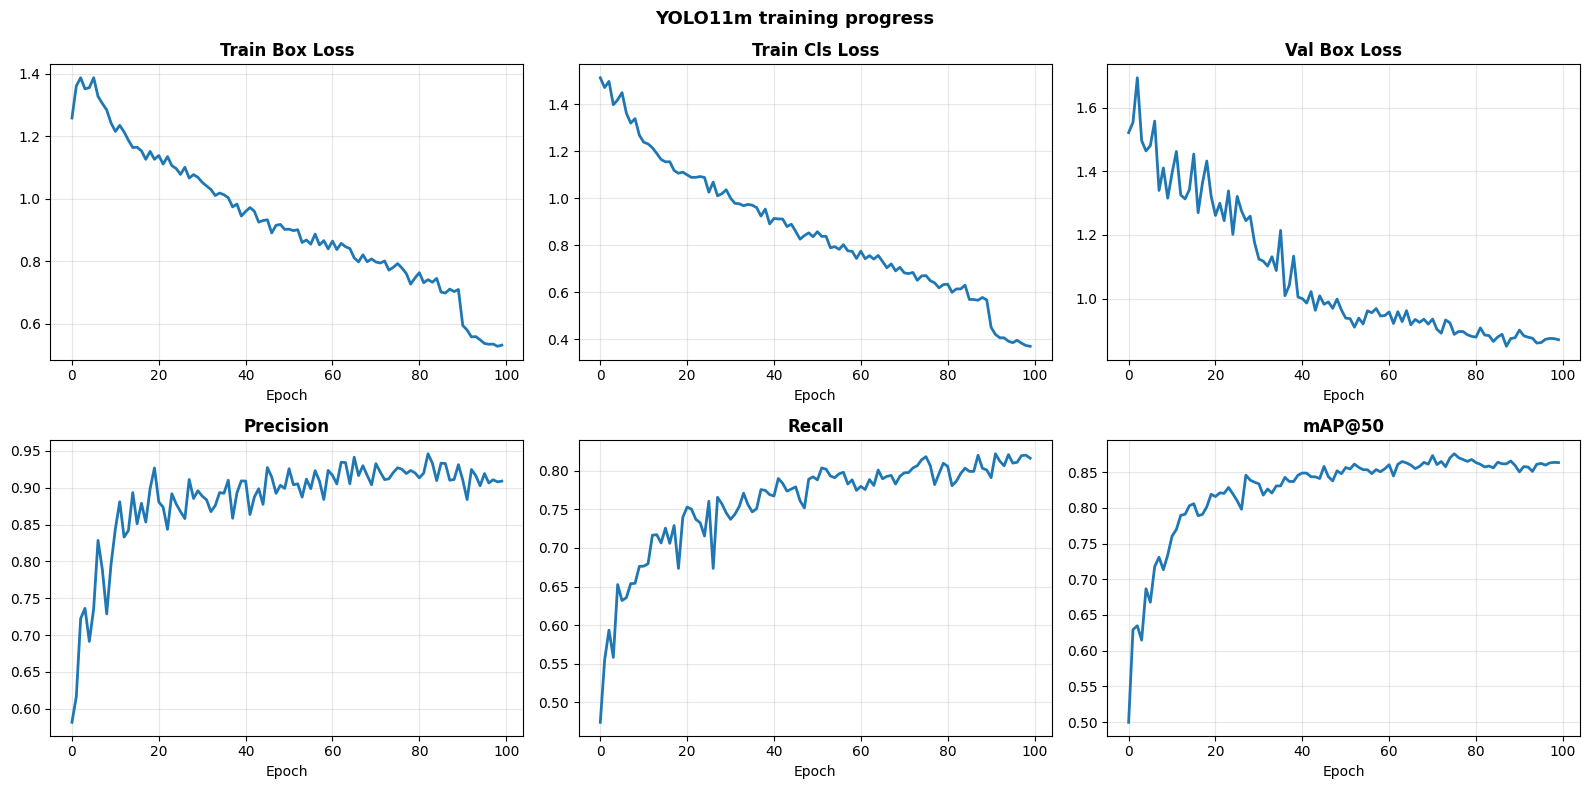

Saved -> C:\Users\fares\Downloads\manual_video_annotations 2\graphs\training_curves.png


In [11]:
# ── Training curves (saved to graphs/) ──────────────────────
results_csv = MODEL_DIR / "yolo11m_littering" / "results.csv"

if not results_csv.exists():
    print("results.csv not found -- skipping curves")
else:
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()
    plots = [
        ("train/box_loss",       "Train Box Loss"),
        ("train/cls_loss",       "Train Cls Loss"),
        ("val/box_loss",         "Val Box Loss"),
        ("metrics/precision(B)", "Precision"),
        ("metrics/recall(B)",    "Recall"),
        ("metrics/mAP50(B)",     "mAP@50"),
    ]
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    for ax, (col, title) in zip(axes.flat, plots):
        if col in df.columns:
            ax.plot(df[col].values, lw=2)
            ax.set_title(title, fontweight="bold")
            ax.set_xlabel("Epoch"); ax.grid(alpha=0.3)
        else:
            ax.set_visible(False)
    plt.suptitle("YOLO11m training progress", fontsize=13, fontweight="bold")
    plt.tight_layout()
    out_png = GRAPHS_DIR / "training_curves.png"
    plt.savefig(out_png, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {out_png}")


## 6. Evaluation  (skippable: `SKIP_EVAL = True`)

In [12]:
# ── Validate best.pt on held-out set (chart saved to graphs/) ──
if SKIP_EVAL:
    print("SKIP_EVAL=True -> skipping validation")
elif not BEST_MODEL.exists():
    print(f"No trained model at {BEST_MODEL} -- run training first")
else:
    eval_model = YOLO(str(BEST_MODEL))
    val_results = eval_model.val(
        data=str(YAML_PATH), imgsz=IMGSZ, batch=BATCH, device=DEVICE,
        verbose=True, plots=True,
        project=str(MODEL_DIR), name="eval", exist_ok=True,
    )

    print(f"\n{'Class':<12}{'Prec':>8}{'Recall':>8}{'mAP50':>8}{'mAP50-95':>10}")
    print("-" * 46)
    for i, name in enumerate(CLASS_NAMES):
        print(f"{name:<12}"
              f"{float(val_results.box.p[i]):>8.3f}"
              f"{float(val_results.box.r[i]):>8.3f}"
              f"{float(val_results.box.ap50[i]):>8.3f}"
              f"{float(val_results.box.ap[i]):>10.3f}")
    print(f"{'ALL':<12}"
          f"{float(val_results.box.mp):>8.3f}"
          f"{float(val_results.box.mr):>8.3f}"
          f"{float(val_results.box.map50):>8.3f}"
          f"{float(val_results.box.map):>10.3f}")

    metrics = {
        "Precision": [float(val_results.box.p[i])    for i in range(len(CLASS_NAMES))],
        "Recall":    [float(val_results.box.r[i])    for i in range(len(CLASS_NAMES))],
        "mAP50":     [float(val_results.box.ap50[i]) for i in range(len(CLASS_NAMES))],
        "mAP50-95":  [float(val_results.box.ap[i])   for i in range(len(CLASS_NAMES))],
    }
    fig, ax = plt.subplots(figsize=(10, 4.5))
    x = np.arange(len(CLASS_NAMES)); width = 0.2
    for i, (m, vals) in enumerate(metrics.items()):
        ax.bar(x + i*width, vals, width, label=m)
    ax.set_xticks(x + 1.5*width); ax.set_xticklabels(CLASS_NAMES)
    ax.set_ylim(0, 1.05); ax.set_ylabel("Score"); ax.legend()
    ax.set_title("Per-class validation metrics", fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    out_png = GRAPHS_DIR / "validation_metrics.png"
    plt.savefig(out_png, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved -> {out_png}")


SKIP_EVAL=True -> skipping validation


## 7. Littering Detection Pipeline

YOLO11m + ByteTrack are **unchanged** — the boxes shown in the output are exactly the model's
output. Only the event-trigger logic has been hardened.

### Key reliability fixes

| Fix | Why it matters |
|---|---|
| **Silent calibration pre-pass** | Old code suppressed events for the first 3 s while drawing a "CALIBRATING" banner. On short clips the drop often happened *inside* that window. The new pre-pass sweeps 20 sampled frames in the first 2 s **before** writing any frames, then runs the main pass with detection live from frame 0. |
| **Per-track suppression** | Old code used a global 3-second cooldown after any fire — second drops in multi-drop scenes were blocked. Now suppression is per-trash-track. |
| **Carry-check** | The model detects trash *while it's still in someone's hand*. If we let that fire, we get a false-positive before the drop and the real drop gets blocked. **The detector now skips firing whenever the trash center sits in the upper 60% of any person's bbox** (held at chest/hand level). The alert waits for the trash to leave the person's hand. |
| **Recent-event spatial suppression** | After firing, the same drop sometimes gets re-detected as a different track (ID switch) or co-detection (bag + bottle). Within `RECENT_EVENT_RADIUS_PX = 200` px and `RECENT_EVENT_WINDOW_SEC = 2` s of a fire, no new event fires. Different drops in different places are not affected. |
| **Confirmation buffer** | Trash must persist for `CONFIRM_FRAMES` frames before firing — kills single-frame flickers. |
| **Smoothed confidence** | Rolling average over `CONF_SMOOTH_WIN` frames must exceed `MIN_AVG_CONF`. |
| **Multi-point person distance** | Min over foot / center / head distance — catches hand-level drops. |
| **Adaptive proximity** | Radius scales with person bbox height for varied camera distance. |


In [13]:
# ── LitteringDetector ───────────────────────────────────────
class LitteringDetector:
    """
    Detect littering events in fixed-camera video.

    YOLO11m + ByteTrack do detection/tracking (unchanged).
    This class only owns the event-trigger heuristics.
    """

    _COL_PERSON = (0, 220, 0)
    _COL_TRASH  = (0, 80, 255)
    _COL_EVENT  = (0, 0, 220)

    def __init__(
        self,
        model_path,
        output_dir,
        evidence_dir,
        fps                      = 25.0,
        conf_thresh              = 0.30,
        proximity_px             = 320,
        calibration_sec          = 2.0,
        banner_sec               = 2.5,
        new_trash_sec            = 10.0,
        established_sec          = 60.0,
        known_dist_px            = 100,
        confirm_frames           = 2,
        track_merge_px           = 70,
        conf_smooth_win          = 5,
        min_avg_conf             = 0.30,
        carried_top_frac         = 0.60,
        recent_event_radius_px   = 200,
        recent_event_window_sec  = 2.0,
    ):
        self.model        = YOLO(model_path)
        self.output_dir   = Path(output_dir);   self.output_dir.mkdir(parents=True, exist_ok=True)
        self.evidence_dir = Path(evidence_dir); self.evidence_dir.mkdir(parents=True, exist_ok=True)

        self.fps              = fps
        self.conf_thresh      = conf_thresh
        self.proximity_px     = proximity_px
        self.calibration_sec  = calibration_sec
        self.banner_frames    = int(banner_sec * fps)
        self.new_thresh       = int(new_trash_sec * fps)
        self.established_thr  = int(established_sec * fps)
        self.known_dist_px    = known_dist_px
        self.confirm_frames   = confirm_frames
        self.track_merge_px   = track_merge_px
        self.conf_smooth_win  = conf_smooth_win
        self.min_avg_conf     = min_avg_conf

        # Carry-check + recent-event-suppression knobs
        self.carried_top_frac          = carried_top_frac
        self.recent_event_radius_px    = recent_event_radius_px
        self.recent_event_window_frames = int(recent_event_window_sec * fps)

        self._reset_state()

    def _reset_state(self):
        self.known_positions  = []
        self.trash_first_seen = {}
        self.trash_centers    = {}
        self.trash_last_seen  = {}
        self.trash_conf_hist  = defaultdict(lambda: deque(maxlen=self.conf_smooth_win))
        self.candidate_streak = defaultdict(int)
        self.fired_tids       = set()    # per-track suppression
        self.event_positions  = []       # list of (frame_idx, cx, cy) for recent-event check
        self.littering_events = []

    # ── geometry ────────────────────────────────────────────
    @staticmethod
    def _center(xyxy): return ((xyxy[0]+xyxy[2])/2, (xyxy[1]+xyxy[3])/2)
    @staticmethod
    def _foot(xyxy):   return ((xyxy[0]+xyxy[2])/2, float(xyxy[3]))
    @staticmethod
    def _head(xyxy):   return ((xyxy[0]+xyxy[2])/2, float(xyxy[1]))
    @staticmethod
    def _dist(a, b):   return ((a[0]-b[0])**2 + (a[1]-b[1])**2) ** 0.5

    def _is_known(self, cx, cy):
        return any(self._dist((cx, cy), (kx, ky)) < self.known_dist_px
                   for kx, ky in self.known_positions)

    def _is_being_carried(self, trash_xy, person_xyxy):
        """
        True if the trash center sits in the upper portion of the person bbox
        (i.e., somewhere between head and waist) -- treat as being held.
        """
        px0, py0, px1, py1 = person_xyxy
        if not (px0 <= trash_xy[0] <= px1):
            return False
        cutoff_y = py0 + self.carried_top_frac * (py1 - py0)
        return trash_xy[1] < cutoff_y

    def _is_near_recent_event(self, cx, cy, frame_idx):
        """True if a fire happened recently within recent_event_radius_px of (cx, cy)."""
        for (ef, ex, ey) in self.event_positions:
            if frame_idx - ef > self.recent_event_window_frames:
                continue
            if self._dist((cx, cy), (ex, ey)) < self.recent_event_radius_px:
                return True
        return False

    def _adaptive_proximity(self, person_xyxy):
        """Scale proximity with person bbox height (closer = bigger pixels)."""
        h = float(person_xyxy[3] - person_xyxy[1])
        return float(np.clip(2.0 * h, self.proximity_px, self.proximity_px * 2))

    def _person_to_trash_dist(self, person_xyxy, trash_xy):
        """Min over foot, center, head distance to the trash center."""
        return min(
            self._dist(self._foot(person_xyxy),   trash_xy),
            self._dist(self._center(person_xyxy), trash_xy),
            self._dist(self._head(person_xyxy),   trash_xy),
        )

    def _maybe_merge_track(self, tid, cx, cy, frame_idx):
        """If a brand-new track appears near a recent one, inherit its history."""
        if tid in self.trash_first_seen:
            return
        best, best_d = None, self.track_merge_px
        for prev_tid, prev_xy in self.trash_centers.items():
            if prev_tid == tid:
                continue
            if frame_idx - self.trash_last_seen.get(prev_tid, 0) > int(self.fps):
                continue
            d = self._dist((cx, cy), prev_xy)
            if d < best_d:
                best, best_d = prev_tid, d
        if best is not None:
            self.trash_first_seen[tid] = self.trash_first_seen[best]
            self.trash_conf_hist[tid]  = self.trash_conf_hist[best].copy()
            if best in self.fired_tids:
                self.fired_tids.add(tid)
        else:
            self.trash_first_seen[tid] = frame_idx

    # ── silent calibration pre-pass ──────────────────────────
    def _calibrate(self, video_path):
        cap = cv2.VideoCapture(str(video_path))
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        fps   = cap.get(cv2.CAP_PROP_FPS) or self.fps
        n_frames = min(int(self.calibration_sec * fps), max(1, total // 4))
        step = max(1, n_frames // 20)

        for i in range(0, n_frames, step):
            cap.set(cv2.CAP_PROP_POS_FRAMES, i)
            ok, frame = cap.read()
            if not ok:
                continue
            res = self.model.predict(
                frame, conf=self.conf_thresh, classes=[1],
                verbose=False, imgsz=IMGSZ,
            )
            if res[0].boxes is None:
                continue
            for box in res[0].boxes:
                xyxy = box.xyxy[0].cpu().numpy()
                cx, cy = self._center(xyxy)
                if not self._is_known(cx, cy):
                    self.known_positions.append((cx, cy))
        cap.release()
        return len(self.known_positions)

    # ── drawing ──────────────────────────────────────────────
    def _draw_frame(self, frame, persons, trash, frame_idx, banner_active):
        img = frame.copy()
        h, w = img.shape[:2]

        for p in persons:
            x1, y1, x2, y2 = map(int, p["xyxy"])
            cv2.rectangle(img, (x1, y1), (x2, y2), self._COL_PERSON, 2)
            cv2.putText(img, f"person {p['conf']:.2f}", (x1, max(y1-6, 12)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, self._COL_PERSON, 2)

        for t in trash:
            x1, y1, x2, y2 = map(int, t["xyxy"])
            col = self._COL_EVENT if t.get("is_event") else self._COL_TRASH
            cv2.rectangle(img, (x1, y1), (x2, y2), col, 2)
            cv2.putText(img, f"trash {t['conf']:.2f}", (x1, max(y1-6, 12)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, col, 2)

        if banner_active > 0:
            cv2.rectangle(img, (0, 0), (w, 50), (0, 0, 0), -1)
            cv2.putText(img, "! LITTERING DETECTED !", (12, 38),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.2, self._COL_EVENT, 3)

        ts = frame_idx / self.fps
        ts_str = f"{int(ts//3600):02d}:{int((ts%3600)//60):02d}:{int(ts%60):02d}"
        cv2.putText(img, ts_str, (8, h-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (220, 220, 220), 1)
        return img

    def _save_evidence(self, drawn, frame_idx, video_stem):
        ts = frame_idx / self.fps
        fname = (f"{video_stem}_"
                 f"{int(ts//3600):02d}{int((ts%3600)//60):02d}{int(ts%60):02d}"
                 f"_frame{frame_idx}.jpg")
        cv2.imwrite(str(self.evidence_dir / fname), drawn)
        return fname

    # ── main entry point ─────────────────────────────────────
    def process(self, video_path):
        self._reset_state()
        video_path = Path(video_path)

        print(f"\n  > {video_path.name}")
        n_static = self._calibrate(video_path)
        print(f"    calibrated -- learned {n_static} static trash position(s)")

        cap = cv2.VideoCapture(str(video_path))
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        w     = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        h     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps   = cap.get(cv2.CAP_PROP_FPS) or self.fps
        cap.release()

        out_video = self.output_dir / f"{video_path.stem}_annotated.mp4"
        writer = cv2.VideoWriter(str(out_video), cv2.VideoWriter_fourcc(*"mp4v"),
                                 fps, (w, h))

        frame_idx     = 0
        banner_active = 0
        pbar = tqdm(total=total, desc="    detecting", unit="f", leave=False)

        for result in self.model.track(
            source  = str(video_path),
            stream  = True, persist = True,
            tracker = "bytetrack.yaml",
            conf    = self.conf_thresh, iou = 0.5,
            classes = [0, 1], verbose = False, imgsz = IMGSZ,
        ):
            frame = result.orig_img
            persons, trash = [], []
            present_tids = set()

            if result.boxes is not None and result.boxes.id is not None:
                for box in result.boxes:
                    cls  = int(box.cls.item())
                    tid  = int(box.id.item())
                    conf = float(box.conf.item())
                    xyxy = box.xyxy[0].cpu().numpy()
                    cx, cy = self._center(xyxy)

                    if cls == 0:
                        persons.append(dict(xyxy=xyxy, id=tid, conf=conf))
                    elif cls == 1:
                        self._maybe_merge_track(tid, cx, cy, frame_idx)
                        self.trash_centers[tid]   = (cx, cy)
                        self.trash_last_seen[tid] = frame_idx
                        self.trash_conf_hist[tid].append(conf)
                        trash.append(dict(xyxy=xyxy, id=tid, conf=conf,
                                          cx=cx, cy=cy, is_event=False))
                        present_tids.add(tid)

            for tid in list(self.candidate_streak.keys()):
                if tid not in present_tids:
                    self.candidate_streak[tid] = 0

            for tid, first in self.trash_first_seen.items():
                if frame_idx - first > self.established_thr:
                    pos = self.trash_centers.get(tid)
                    if pos and not self._is_known(*pos):
                        self.known_positions.append(pos)

            if banner_active > 0:
                banner_active -= 1

            if persons:
                for t in trash:
                    tid = t["id"]
                    if tid in self.fired_tids:
                        continue

                    age = frame_idx - self.trash_first_seen.get(tid, frame_idx)
                    is_new   = age <= self.new_thresh
                    is_novel = not self._is_known(t["cx"], t["cy"])
                    hist = self.trash_conf_hist[tid]
                    avg_conf = sum(hist) / len(hist) if hist else 0.0
                    if not (is_new and is_novel and avg_conf >= self.min_avg_conf):
                        self.candidate_streak[tid] = 0
                        continue

                    # CARRY-CHECK: any person holding this trash? -> wait for the drop
                    if any(self._is_being_carried((t["cx"], t["cy"]), p["xyxy"])
                           for p in persons):
                        self.candidate_streak[tid] = 0
                        continue

                    # RECENT-EVENT CHECK: was a fire just nearby? -> same drop, suppress
                    if self._is_near_recent_event(t["cx"], t["cy"], frame_idx):
                        self.candidate_streak[tid] = 0
                        continue

                    # Find nearest person using multi-point distance + adaptive radius
                    best_d, best_p = float("inf"), None
                    for p in persons:
                        radius = self._adaptive_proximity(p["xyxy"])
                        d = self._person_to_trash_dist(p["xyxy"], (t["cx"], t["cy"]))
                        if d < radius and d < best_d:
                            best_d, best_p = d, p

                    if best_p is None:
                        self.candidate_streak[tid] = 0
                        continue

                    # Persistence buffer
                    self.candidate_streak[tid] += 1
                    if self.candidate_streak[tid] < self.confirm_frames:
                        continue

                    # ── FIRE EVENT ──
                    t["is_event"] = True
                    banner_active = self.banner_frames
                    drawn = self._draw_frame(frame, persons, trash, frame_idx, banner_active)
                    fname = self._save_evidence(drawn, frame_idx, video_path.stem)
                    ts = frame_idx / fps
                    ev = dict(
                        frame       = frame_idx,
                        timestamp   = f"{int(ts//3600):02d}:{int((ts%3600)//60):02d}:{int(ts%60):02d}",
                        seconds     = round(ts, 2),
                        screenshot  = fname,
                        dist_px     = round(best_d, 1),
                        person_conf = round(best_p["conf"], 3),
                        trash_conf  = round(avg_conf, 3),
                    )
                    self.littering_events.append(ev)
                    self.fired_tids.add(tid)
                    self.event_positions.append((frame_idx, t["cx"], t["cy"]))
                    self.known_positions.append((t["cx"], t["cy"]))
                    self.candidate_streak[tid] = 0
                    tqdm.write(f"    [EVENT] @ {ev['timestamp']}  "
                               f"dist={best_d:.0f}px  avg_conf={avg_conf:.2f}")

            drawn = self._draw_frame(frame, persons, trash, frame_idx, banner_active)
            writer.write(drawn)
            frame_idx += 1
            pbar.update(1)

        pbar.close()
        writer.release()
        print(f"    Done -- {len(self.littering_events)} event(s)  |  {out_video.name}")
        return self.littering_events, out_video

print("LitteringDetector ready.")


LitteringDetector ready.


## 8. Run on Videos in `input/`

Drop any `.mp4` / `.avi` / `.mov` / `.mkv` / `.m4v` file into `input/`.

Output layout (all four folders are siblings at project root):
```
outputs/    <video>_annotated.mp4
evidence/   <video>_HHMMSS_frameN.jpg
graphs/     <visualization>.png
```


In [18]:
# ── Optional: clean old run-folders from previous notebook versions ─
old_runs = sorted(OUTPUT_DIR.glob("*_run_*"))
if old_runs:
    print(f"Found {len(old_runs)} old run-folder(s) from a previous version:")
    for d in old_runs:
        print(f"  - {d.name}")
    print("\nUncomment the line below to delete them:")
    # for d in old_runs: shutil.rmtree(d)


In [19]:
# ── Process every video in input/ ───────────────────────────
if not BEST_MODEL.exists():
    raise FileNotFoundError(f"No trained model at {BEST_MODEL}")

VIDEO_EXTS = {".mp4", ".avi", ".mov", ".mkv", ".m4v"}
videos = sorted(f for f in INPUT_DIR.iterdir() if f.suffix.lower() in VIDEO_EXTS)

if not videos:
    print(f"No videos in {INPUT_DIR}.  Drop files there and re-run.")
    all_results = []
else:
    print(f"Found {len(videos)} video(s):")
    for v in videos:
        print(f"  - {v.name}")

    detector = LitteringDetector(
        model_path             = str(BEST_MODEL),
        output_dir             = str(OUTPUT_DIR),
        evidence_dir           = str(EVIDENCE_DIR),
        fps                    = VIDEO_FPS,
        conf_thresh            = CONF_THRESH,
        proximity_px           = PROXIMITY_PX,
        calibration_sec        = CALIBRATION_SEC,
        banner_sec             = BANNER_SEC,
        new_trash_sec          = NEW_TRASH_SEC,
        established_sec        = ESTABLISHED_SEC,
        known_dist_px          = KNOWN_DIST_PX,
        confirm_frames         = CONFIRM_FRAMES,
        track_merge_px         = TRACK_MERGE_PX,
        conf_smooth_win        = CONF_SMOOTH_WIN,
        min_avg_conf           = MIN_AVG_CONF,
        carried_top_frac       = CARRIED_TOP_FRAC,
        recent_event_radius_px = RECENT_EVENT_RADIUS_PX,
        recent_event_window_sec= RECENT_EVENT_WINDOW_SEC,
    )

    all_results = []
    for i, vid in enumerate(videos, 1):
        print(f"\n[{i}/{len(videos)}]", end="")
        events, out_vid = detector.process(vid)
        all_results.append((vid, events, out_vid))

    print(f"\n{'='*60}\n  All videos processed.\n{'='*60}")


Found 12 video(s):
  - Suits.mp4
  - two_people_drops_near_existing_trash.mp4
  - two_people_one_drops.mp4
  - walks_near_existing_trash_no_drop.mp4
  - YTDown_YouTube_JAYKEEOUT_Throwing_Trash_on_Streets_Expe_Media_GVz1CdfXDx8 (2).mp4
  - YTDown_YouTube_JAYKEEOUT_Throwing_Trash_on_Streets_Expe_Media_GVz1CdfXDx8 (3).mp4
  - YTDown_YouTube_JAYKEEOUT_Throwing_Trash_on_Streets_Expe_Media_GVz1CdfXDx8 (4).mp4
  - YTDown_YouTube_JAYKEEOUT_Throwing_Trash_on_Streets_Expe_Media_GVz1CdfXDx8 (5).mp4
  - YTDown_YouTube_JAYKEEOUT_Throwing_Trash_on_Streets_Expe_Media_GVz1CdfXDx8 (6).mp4
  - YTDown_YouTube_JAYKEEOUT_Throwing_Trash_on_Streets_Expe_Media_GVz1CdfXDx8 (7).mp4
  - YTDown_YouTube_JAYKEEOUT_Throwing_Trash_on_Streets_Expe_Media_GVz1CdfXDx8 (8).mp4
  - YTDown_YouTube_JAYKEEOUT_Throwing_Trash_on_Streets_Expe_Media_GVz1CdfXDx8.mp4

[1/12]
  > Suits.mp4
    calibrated -- learned 0 static trash position(s)


    detecting:  78%|███████▊  | 139/179 [00:02<00:00, 50.38f/s]

    [EVENT] @ 00:00:04  dist=311px  avg_conf=0.63


    Done -- 1 event(s)  |  Suits_annotated.mp4

[2/12]
  > two_people_drops_near_existing_trash.mp4
    calibrated -- learned 2 static trash position(s)


    detecting:  55%|█████▍    | 106/193 [00:02<00:02, 39.16f/s]

...

    Done -- 0 event(s)  |  YTDown_YouTube_JAYKEEOUT_Throwing_Trash_on_Streets_Expe_Media_GVz1CdfXDx8 (5)_annotated.mp4

[9/12]
  > YTDown_YouTube_JAYKEEOUT_Throwing_Trash_on_Streets_Expe_Media_GVz1CdfXDx8 (6).mp4
    calibrated -- learned 0 static trash position(s)


    Done -- 0 event(s)  |  YTDown_YouTube_JAYKEEOUT_Throwing_Trash_on_Streets_Expe_Media_GVz1CdfXDx8 (6)_annotated.mp4

[10/12]
  > YTDown_YouTube_JAYKEEOUT_Throwing_Trash_on_Streets_Expe_Media_GVz1CdfXDx8 (7).mp4
    calibrated -- learned 0 static trash position(s)


    Done -- 0 event(s)  |  YTDown_YouTube_JAYKEEOUT_Throwing_Trash_on_Streets_Expe_Media_GVz1CdfXDx8 (7)_annotated.mp4

[11/12]
  > YTDown_YouTube_JAYKEEOUT_Throwing_Trash_on_Streets_Expe_Media_GVz1CdfXDx8 (8).mp4
    calibrated -- learned 0 static trash position(s)


    Done -- 0 event(s)  |  YTDown_YouTube_JAYKEEOUT_Throwing_Trash_on_Streets_Expe_Media_GVz1CdfXDx8 (8)_annotated.mp4

[12/12]
  > YTDown_YouTube_JAYKEEOUT_Throwing_Trash_on_Streets_Expe_Media_GVz1CdfXDx8.mp4
    calibrated -- learned 0 static trash position(s)


    Done -- 0 event(s)  |  YTDown_YouTube_JAYKEEOUT_Throwing_Trash_on_Streets_Expe_Media_GVz1CdfXDx8_annotated.mp4

  All videos processed.


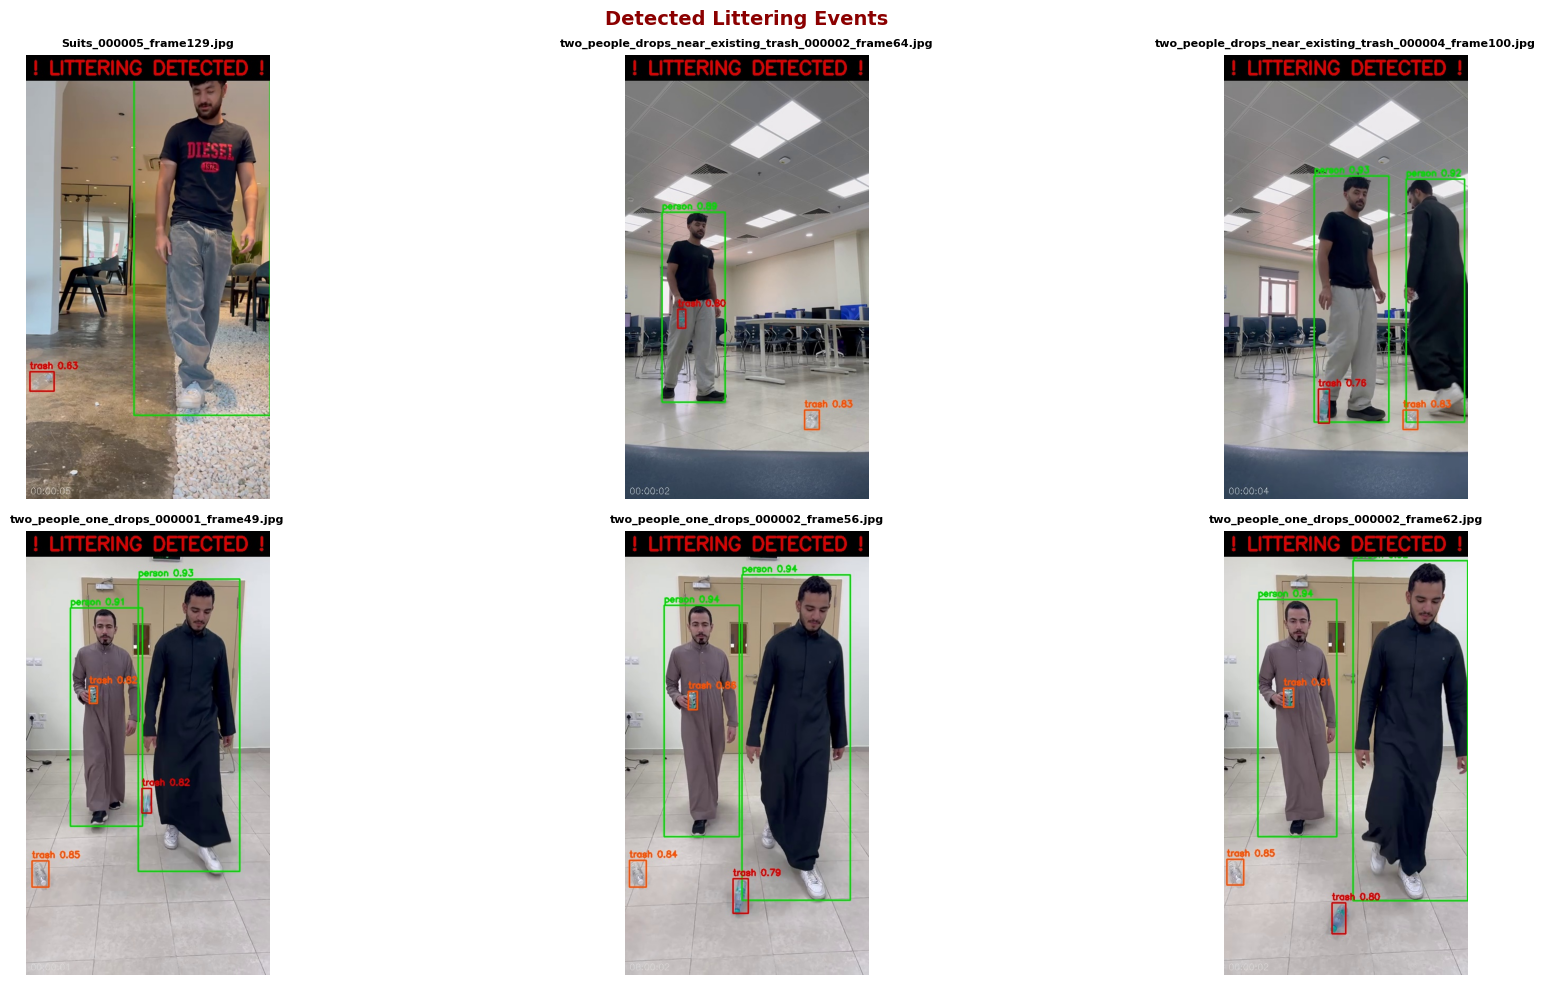


Saved gallery -> C:\Users\fares\Downloads\manual_video_annotations 2\graphs\events_gallery.png


In [16]:
# ── Display all event screenshots from evidence/ ────────────
all_shots = sorted(EVIDENCE_DIR.glob("*.jpg"))

if not all_shots:
    print("No littering events detected.")
    print("Tuning suggestions if you expected events:")
    print(f"  - Lower CONF_THRESH (currently {CONF_THRESH}) to 0.20")
    print(f"  - Lower CONFIRM_FRAMES (currently {CONFIRM_FRAMES}) to 1")
    print(f"  - Increase PROXIMITY_PX (currently {PROXIMITY_PX}) to 450")
    print(f"  - Lower MIN_AVG_CONF (currently {MIN_AVG_CONF}) to 0.20")
else:
    cols = min(3, len(all_shots))
    rows = (len(all_shots) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(7*cols, 5*rows))
    if rows == 1 and cols == 1:
        axes = [axes]
    axes = np.array(axes).flatten()
    for ax, img_path in zip(axes, all_shots):
        ax.imshow(np.array(Image.open(img_path).convert("RGB")))
        ax.set_title(img_path.name, fontsize=8, fontweight="bold")
        ax.axis("off")
    for ax in axes[len(all_shots):]:
        ax.axis("off")
    plt.suptitle("Detected Littering Events", fontsize=14,
                 fontweight="bold", color="darkred")
    plt.tight_layout()
    out_png = GRAPHS_DIR / "events_gallery.png"
    plt.savefig(out_png, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"\nSaved gallery -> {out_png}")


In [17]:
# ── Final summary ───────────────────────────────────────────
print("="*70)
print("  LITTERING DETECTION  --  SUMMARY")
print("="*70)
print(f"  Model              : {BEST_MODEL}")
print(f"  Input  folder      : {INPUT_DIR}")
print(f"  Annotated videos   : {OUTPUT_DIR}")
print(f"  Evidence (JPGs)    : {EVIDENCE_DIR}")
print(f"  Graphs             : {GRAPHS_DIR}")
print()

if not all_results:
    print("  No videos processed.")
else:
    total_events = 0
    for vid, events, out_vid in all_results:
        total_events += len(events)
        print(f"  Video  : {vid.name}")
        print(f"    Output : {out_vid.name}")
        print(f"    Events : {len(events)}")
        if events:
            print(f"    {'#':<4}{'Time':>10}{'Frame':>8}{'Dist':>7}{'Person':>9}{'Trash':>8}  Evidence")
            print(f"    {'-'*72}")
            for i, e in enumerate(events, 1):
                print(f"    {i:<4}{e['timestamp']:>10}{e['frame']:>8}"
                      f"{e['dist_px']:>7.0f}{e['person_conf']:>9.2f}"
                      f"{e['trash_conf']:>8.2f}  {e['screenshot']}")
        print()
    print(f"  Total events across all videos: {total_events}")


  LITTERING DETECTION  --  SUMMARY
  Model              : C:\Users\fares\Downloads\manual_video_annotations 2\littering_model\yolo11m_littering\weights\best.pt
  Input  folder      : C:\Users\fares\Downloads\manual_video_annotations 2\input
  Annotated videos   : C:\Users\fares\Downloads\manual_video_annotations 2\outputs
  Evidence (JPGs)    : C:\Users\fares\Downloads\manual_video_annotations 2\evidence
  Graphs             : C:\Users\fares\Downloads\manual_video_annotations 2\graphs

  Video  : Suits.mp4
    Output : Suits_annotated.mp4
    Events : 1
    #         Time   Frame   Dist   Person   Trash  Evidence
    ------------------------------------------------------------------------
    1     00:00:04     129    311     0.93    0.63  Suits_000005_frame129.jpg

  Video  : two_people_drops_near_existing_trash.mp4
    Output : two_people_drops_near_existing_trash_annotated.mp4
    Events : 1
    #         Time   Frame   Dist   Person   Trash  Evidence
    ---------------------------

## 9. Notes & Limitations

### What's actually doing the heavy lifting

- **YOLO11m + ByteTrack** — detection + ID assignment (unchanged).
- **Silent calibration pre-pass** — learns pre-existing trash without blocking event firing.
- **Carry-check** — alert waits for the trash to leave the person's hand; eliminates the "warn before throw" failure mode.
- **Recent-event spatial suppression** — same drop can't fire twice via ID switch / co-detection.
- **Per-track suppression** — multi-drop scenes catch every drop instead of being blocked by a global cooldown.

### Known limitations

| Limitation | Cause |
|---|---|
| Wind-displaced trash drifting far from its calibration position | Position-based "known" cache |
| Multiple people grouped together | Algorithm reports the nearest person — no per-person attribution |
| Person throws trash *upward / sideways* (model sees trash above feet) | Carry-check assumes the drop ends below upper 60% of bbox |
| Heavily occluded drops | Smoothed average may stay below `MIN_AVG_CONF` |
| Night-time footage | YOLO11m COCO weights biased toward daytime |

### Reproducibility

- Random seed fixed to `42`
- Augmentation auto-scales with dataset size
- Best weights saved at `littering_model/yolo11m_littering/weights/best.pt`
- Output filenames embed timestamp/frame — reruns overwrite same-name files
